**Name : Karl NGANKAM**

In [2]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 


In [3]:
ticker1 ='V'
ticker2 = 'MA'
data1 = yf.download(ticker1, start = '2012-04-01', end = '2026-04-03').loc[:,'Close']
data2 = yf.download(ticker2, start = '2012-04-01', end = '2026-04-03').loc[:,'Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Data we have just imported range from April 2nd 2012 to April 2nd 2026 included, which correspond to 15 years data. 

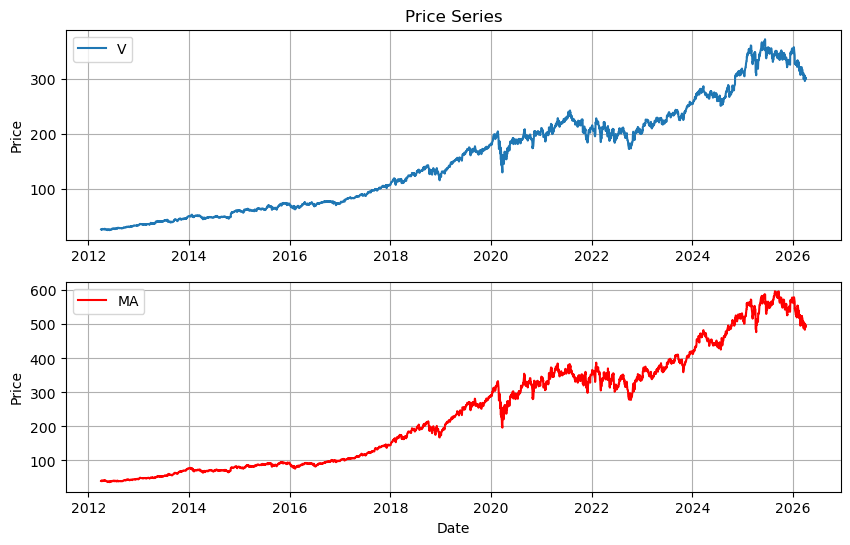

In [4]:
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(data1, label = ticker1)

plt.ylabel('Price')
plt.grid()
plt.legend()
plt.title ('Price Series')
plt.subplot(2,1,2)

plt.plot(data2, label = ticker2, color = 'red')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid()
plt.legend()
plt.show()

Before answering the questions, I felt it was necessary to examine the two time series.

It is clear that these two stocks are trending upward (non-stationary series) and are following a fairly similar pattern. (I believe there is a strong correlation between these two stocks.) 

***1. Question 1:Explanatory Data Analysis (The Spread)***

In [ ]:
#a)
#Logarithmic prices 
log_prices1 =np.log(data1).dropna()
log_prices2 =np.log(data2).dropna()
df = pd.DataFrame({'log_prices1': log_prices1['V'], 'log_prices2': log_prices2['MA']}, index =data1[1:].index.values)

#Spread between the two log price series
df['Spread']= df['log_prices1'] - df['log_prices2']
df

,log_prices1,log_prices2,Spread
2012-04-03,3.303850,3.699514,-0.395665
2012-04-04,3.292318,3.683904,-0.391586
2012-04-05,3.309236,3.704369,-0.395133
2012-04-09,3.296679,3.703095,-0.406416
2012-04-10,3.273312,3.669389,-0.396077
...,...,...,...
2026-03-27,5.688736,6.182581,-0.493844
2026-03-30,5.702248,6.202536,-0.500288
2026-03-31,5.711221,6.213928,-0.502707
2026-04-01,5.698803,6.197767,-0.498964


**b.Plot of the spread**

<Figure size 1000x600 with 0 Axes>

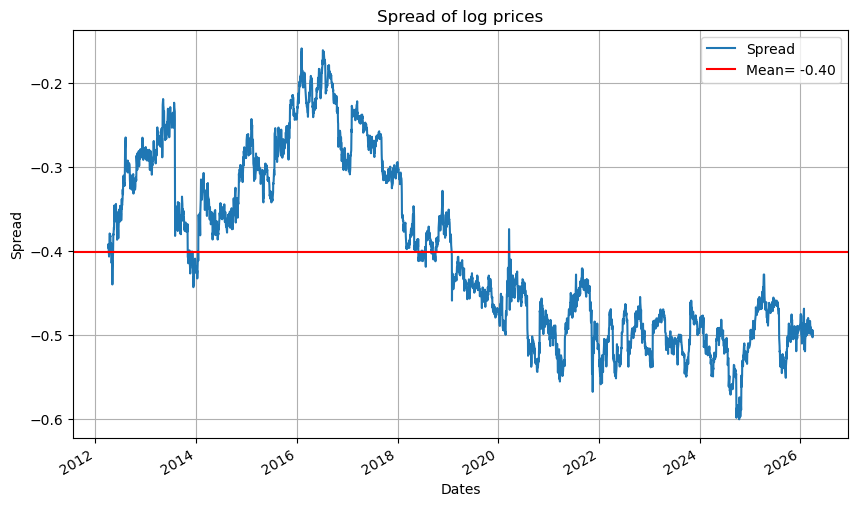

In [6]:
plt.figure(figsize=(10,6))
df.plot(y='Spread', figsize=(10,6))
axhline = plt.axhline(y=(df['Spread']).mean(axis =0), color='red',
                      label= f'Mean= {df["Spread"].mean():.2f}' ,linestyle='-')
plt.title('Spread of log prices')
plt.xlabel('Dates')
plt.ylabel('Spread')
plt.grid()
plt.legend()
plt.show()

**Comments:**

The spread shows strong persitence and does not revert quicly to its mean (-0.4). The series seems to be non-stationary as the mean depends on date t. 

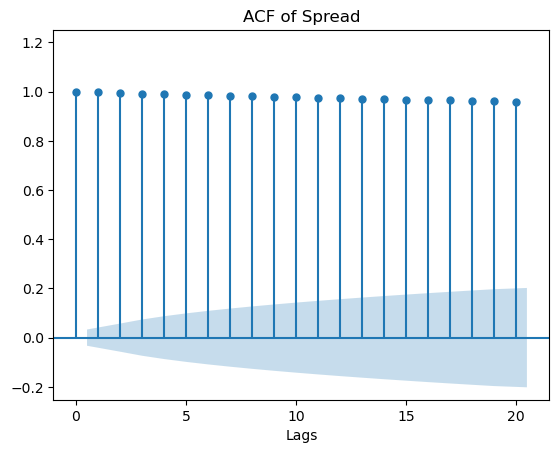

In [7]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['Spread'], lags=20, title='ACF of Spread', auto_ylims=True)
plt.xlabel('Lags')
plt.show()

**Comments:**

Based on the AC curve, the ACF remains close to 1 across multiple lags, indicating a hihgly autocorrelated (and likely non-stationary process). This suggest that shocks to the spread are long-lasting. 

There is little evidence of mean reversion, the 2 assets (V and MA) doesn't appear to form a strongly mean-reverting pair over the chosen period. 


**2: Trading Strategy**

In [8]:
n = df['Spread'].shape[0]
p = int(n/2)
df1 = df['Spread'].iloc[0:p]
df2 = df['Spread'].iloc[p:]

In [9]:
position =0 #cash: 0, buy asset 1: 1, buy asset 2: -1
positions = []
for i in range (len(df2)):
    mu_t = df['Spread'].iloc[0:p+i+1].mean()
    sigma_t = df['Spread'].iloc[0:p+i+1].std()

    if position ==0:
        if df2.iloc[i]< mu_t- sigma_t:
            position = 1  #Buy asset 1

        elif df2.iloc[i]> mu_t + sigma_t:        
            position = -1 #Buy asset 2

    elif position ==1: #we are lon asset 1, we want to sell it when the spread is above the mean
        if df2.iloc[i]>= mu_t:
            position = 0
    elif position ==-1:
        if df2.iloc[i]<= mu_t:
            position = 0

    positions.append(position)
    

*3. Economic Testing*

In [10]:
print(positions.count(1))
print(positions.count(-1))
print (positions.count(0))
#print (p, len(positions))

1760
0
0


All the positions are equal to 1, which means that at time t, the spread is lower than the difference up to time t of the spread_mean and the spread_standard_deviation

In [11]:
#Dummy variable 
Dummy_asset1 = []
for i in range (0, len(positions)):
    if positions[i] ==1:
        Dummy_asset1.append(1)
    else: 
        Dummy_asset1.append(0)
print (len (Dummy_asset1))
print (Dummy_asset1[:10])

1760
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [12]:
#We should create the series of log returns (log differences ln(Pt)-ln(Pt-1)) for the two assets.
returns1= log_prices1.diff().dropna()
returns2= log_prices2.diff().dropna()
print (log_prices1.shape, returns1.shape)

(3521, 1) (3520, 1)


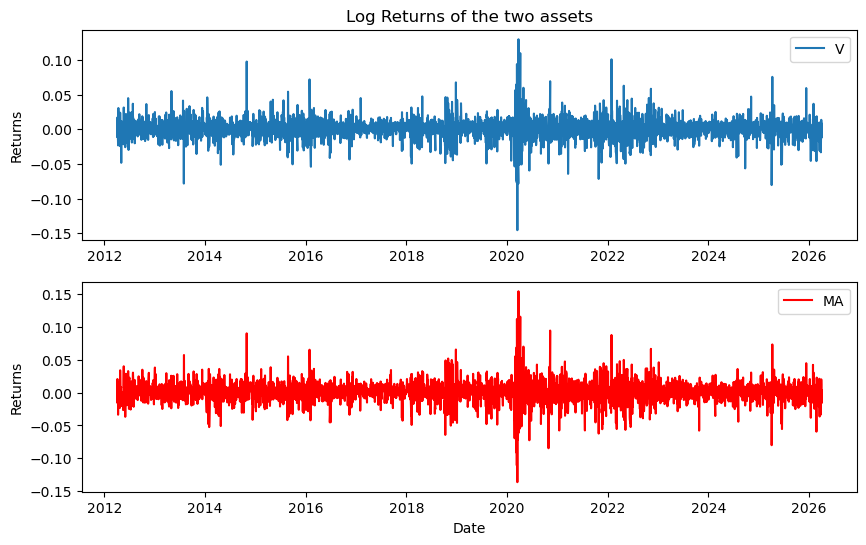

In [13]:
#Before performing the regression, we need to plot the dependent variable and make sure the series is stationary.
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot (returns1, label =ticker1)
plt.ylabel('Returns')
plt.title('Log Returns of the two assets')
plt.legend()

plt.subplot(2,1,2)
plt.plot (returns2, label =ticker2, color = 'red')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

**Comments on the log returns graphs:**

The log-return series appear approximately stationary, as they fluctuate around a constant mean close to zero and do not show a clear trend. However, their volatility seems time-varying. 

In [14]:
import statsmodels.api as sm 

x1 = sm.add_constant(Dummy_asset1[:-1])
y1 = returns1[p+1:]
model1 = sm.OLS(y1,x1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      V   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 08 Apr 2026   Prob (F-statistic):                nan
Time:                        19:32:00   Log-Likelihood:                 4730.4
No. Observations:                1759   AIC:                            -9459.
Df Residuals:                    1758   BIC:                            -9453.
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.001      0.3

**Comments:**

The regression doesn't estimate the coefficient Beta1. This is due to the fact that the spread series is not strongly mean reversible over the sample 2019-2026, which corresponds to the second half of the initial spread's data. As a result, the strategy enters a long position and doesn't exits it, leading to a constant dummy variable (vector of ones). 

To have a better regression, **we will change the way the we split data. We will start at 10% of the sample and rerun the exercise**

In [15]:
start =int(0.1*n)
end = int(0.6*n)

spread_1 = pd.concat([
    df['Spread'].iloc[:start],
    df['Spread'].iloc[end:]
])

spread_2 = df['Spread'].iloc[start:end]
len(spread_1), len(spread_2)

(1760, 1760)

In [16]:
position =0 #cash: 0, buy asset 1: 1, buy asset 2: -1
positions = []
for i in range (len(spread_2)):
    mu_t = df['Spread'].iloc[0:start+i+1].mean()
    sigma_t = df['Spread'].iloc[0:start+i+1].std()

    if position ==0:
        if spread_2.iloc[i]< mu_t- sigma_t:
            position = 1  #Buy asset 1

        elif spread_2.iloc[i]> mu_t + sigma_t:        
            position = -1 #Buy asset 2

    elif position ==1: #we are lon asset 1, we want to sell it when the spread is above the mean
        if spread_2.iloc[i]>= mu_t:
            position = 0
    elif position ==-1:
        if spread_2.iloc[i]<= mu_t:
            position = 0

    positions.append(position)
    

In [17]:
print("1:", positions.count(1))
print("-1:",positions.count(-1))
print ("0:",positions.count(0))
print (len(positions))

1: 864
-1: 590
0: 306
1760


In [18]:
#Let's recreate the dummy variable 
positions =np.array(positions)
Dummy_asset1 = (np.array(positions)==1).astype(int)
Dummy_asset2 = (np.array(positions)==-1).astype(int)
print (len(Dummy_asset1), len(Dummy_asset2))

1760 1760


In [19]:
x1 = sm.add_constant(Dummy_asset1[:-1])
y1 = returns1[start+1:end]
model1 = sm.OLS(y1,x1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      V   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                  0.004717
Date:                Wed, 08 Apr 2026   Prob (F-statistic):              0.945
Time:                        19:32:01   Log-Likelihood:                 4832.8
No. Observations:                1759   AIC:                            -9662.
Df Residuals:                    1757   BIC:                            -9651.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.001      1.802      0.0

**The estimated ß1 coefficient is positive but very small and statistically insignificant**.

In fact, **|t-stat| = 0.217 < 1.96; p-value >0.05: the null-hypothesis is not rejected**. 
In addition, the R^2 coefficient is equal to 0. This indicates that the dummy variable doesn't appear to have a predictive power on the returns of Asset 1.

In [20]:
#2nd Regression
x2 = sm.add_constant(Dummy_asset2[:-1])
y2 = returns2[start+1:end]
model2 = sm.OLS(y2,x2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                     MA   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2185
Date:                Wed, 08 Apr 2026   Prob (F-statistic):              0.640
Time:                        19:32:01   Log-Likelihood:                 4693.4
No. Observations:                1759   AIC:                            -9383.
Df Residuals:                    1757   BIC:                            -9372.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011      0.000      2.322      0.0

***COMMENTS ON THE REGRESSION FOR ASSET 2***

The ß1 coefficient is negative but quite small (-4*10^(-4)) and insignificant as the p-value = 0.640 > 0.05, so the null hypothesis (ß1 = 0) can't be rejected. The R^2 coefficient is equal to 0: **the dummy variable fails to explain the future price of the asset**

***The strategy doesn't successfully predict positive returns***

**4.Economic Performance**

**a. Evolution of the capital**

In [26]:
spread_test = df['Spread'].iloc[start:end]
ret1_test = returns1.iloc[start:end]
ret2_test = returns2.iloc[start:end]


In [34]:
capital =[100]# initial capital
for i in range (1,len(positions)):
    current_capital = capital[-1]

    if positions[i-1] == 1: # we are long asset 1
        new_capital = current_capital * np.exp(ret1_test.iloc[i].values) # update capital based on the return of asset 1
    elif positions[i-1] == -1: # we are long asset 2
        new_capital = current_capital * np.exp(ret2_test.iloc[i].values)
    else: # we are in cash
        new_capital = current_capital 
    capital.append(new_capital)
capital = pd.Series(capital, index = spread_test.index)


In [35]:
#b) With transaction costs (of 0.5%)

c = 0.005 
capital_tc =[100]

for t in range(1, len(positions)):
    current_capital = capital_tc[-1]

    if positions[t] != positions[t-1]: # we are long asset 1
        current_capital *= (1 - c) 

    if positions[t-1] == 1: 
        new_capital = current_capital * np.exp(ret1_test.iloc[t].values)
    elif positions[t-1] == -1:
        new_capital = current_capital * np.exp(ret2_test.iloc[t].values)
    else:
        new_capital = current_capital
    capital_tc.append(new_capital)
capital_tc = pd.Series(capital_tc, index = spread_test.index)

**c. Graphs**

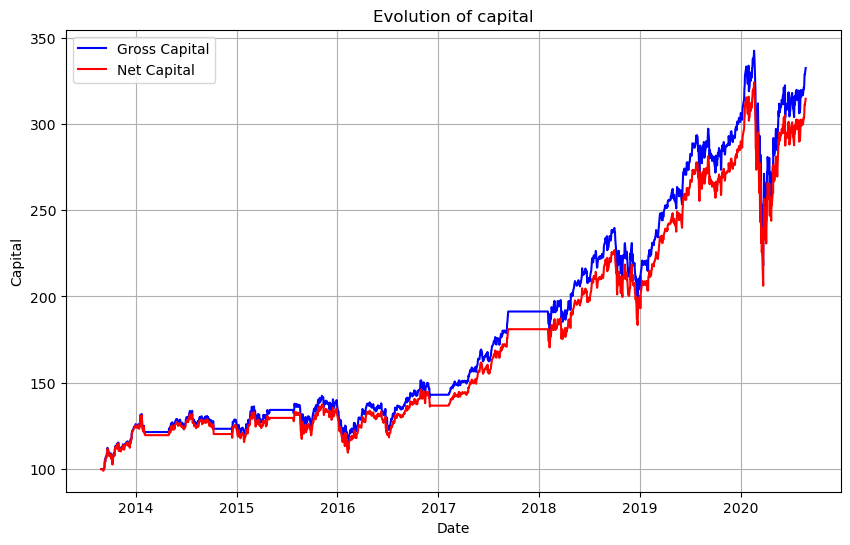

In [41]:
plt.figure(figsize=(10,6))
plt.plot(capital, label='Gross Capital', color = 'blue')
plt.plot(capital_tc, label='Net Capital', color = 'red') 
plt.title('Evolution of capital')
plt.xlabel('Date')
plt.ylabel('Capital')
plt.legend()
plt.grid()
plt.show()

**COMMENTS:**

This strategy generates strong capital growth, increasing capital from $100 to over $300. However, transaction costs reduce performance and widen the gap between gross and net capital, indicating a high frequency of trades. Although the strategy remains profitable after accounting for costs, it experiences significant drawdowns and carries high risk. Combined with the lack of statistical significance in the regression results, this suggests that the observed performance may not reflect a robust predictive strategy.